# Classification d'emplacements de parking par CNN

Les TP 01 a 04 determinent l'etat d'un emplacement de parking (libre / occupe)
avec un descripteur de texture fait main (LBP) et un classifieur au plus
proche voisin. Ce notebook attaque le meme probleme par apprentissage
profond : un petit CNN apprend directement sur les pixels de l'imagette, sans
descripteur intermediaire.

La demarche reprend celle des notebooks de CNN du depot
(`TP_Malware_CNN_Colabnotrunned.ipynb`,
`CNN_Malware_OnOurPythonModel/CNN_Malware_OnOurPythonModel.ipynb`) : verification
de l'environnement, chargement des donnees, architecture, entrainement avec
courbes, puis evaluation. Ce dossier reprend par ailleurs l'organisation des
TP 01-04 : un `README.md`, un dossier `resultats/` et les memes modules
(`dataset.py`, `figstyle.py`) que les TP LBP.

**Protocole**, identique a celui des TP LBP pour rester comparable :

- 100 imagettes libres + 100 occupees pour le training, 100 + 100 *disjointes*
  pour le test (camera A du jeu CNRPark).
- L'experience est repetee sur **10 tirages aleatoires independants**, comme
  `04-parking-lbp-multiechelle/benchmark.py`. Le graphe de synthese (section 5)
  moyenne ces 10 tirages.
- Les graines utilisees (`tirage * 2`) sont **les memes** que celles du
  benchmark LBP multi-echelle : chaque tirage pioche donc exactement les memes
  200 + 200 imagettes des deux cotes. La comparaison de la section 6 se fait
  ainsi a donnees strictement identiques, pas seulement en moyenne.

**Prerequis** : `pip install -r ../requirements.txt` (ajoute `tensorflow` a
la liste des TP LBP), et l'archive CNRPark extraite a la racine du depot
(cf. `README.md`). Un GPU accelere l'entrainement mais n'est pas necessaire :
chaque tirage entraine sur 200 imagettes de 64x64, quelques dizaines de
secondes suffisent sur CPU.

## 0. Verification de l'environnement

In [1]:
import platform
import sys
import time

import numpy as np
import tensorflow as tf

print("Python      :", sys.version.split()[0])
print("Plateforme  :", platform.platform())
print("TensorFlow  :", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU visibles:", gpus or "aucun (l'entrainement se fera sur CPU, c'est suffisant ici)")

Python      : 3.13.9
Plateforme  : Windows-11-10.0.26200-SP0
TensorFlow  : 2.21.0


GPU visibles: aucun (l'entrainement se fera sur CPU, c'est suffisant ici)


## 1. Donnees

Meme jeu que les TP 01-04 : base CNRPark, imagettes 150x150, extraite a la
racine du depot (`../A/free`, `../A/busy`, ...). `dataset.py` est une copie
volontaire de celui des TP LBP (voir l'entete du fichier).

In [2]:
from pathlib import Path

from dataset import LABELS, list_images

TRAIN_ROOT = Path("../A")

for nom, _ in LABELS:
    images = list_images(TRAIN_ROOT / nom)
    print("%-6s : %4d imagettes" % (nom, len(images)))

free   : 2550 imagettes
busy   : 3621 imagettes


## 2. Architecture du CNN

Le jeu training ne compte que 200 imagettes : un CNN profond y sur-apprendrait
immediatement. `cnn.py` definit donc un reseau volontairement petit (3 blocs
convolutifs, une seule couche dense), avec une legere augmentation de donnees
(retournement horizontal, translation) et un arret anticipe sur une
validation decoupee dans le training, pour limiter le sur-apprentissage.

| Couche | Role |
| --- | --- |
| `Rescaling(1/255)` | normalisation des pixels 0-255 en 0-1 |
| `RandomFlip`, `RandomTranslation` | augmentation, actives seulement a l'entrainement |
| 3 x (`Conv2D` + `MaxPooling2D`) | 16, 32, puis 64 filtres |
| `Flatten` + `Dense(64)` + `Dropout(0.5)` | tete de classification |
| `Dense(1, sigmoid)` | probabilite "occupe" |

In [3]:
from cnn import IMG, build_model

build_model(IMG).summary()

Model: "parking_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 64, 64, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 285,569 (1.09 MB)

 Trainable params: 285,569 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Un tirage de demonstration

Premier tirage (graine 0) : 100 + 100 imagettes training, 100 + 100 imagettes
test disjointes. Le training est lui-meme decoupe (80 / 20) pour l'arret
anticipe, la mesure finale se fait sur le jeu test, jamais vu.

In [4]:
from dataset import tirages

training, test = tirages(TRAIN_ROOT, TRAIN_ROOT, 100, 100, seed=0)
print("training :", len(training), "imagettes  |  test :", len(test), "imagettes")

training : 200 imagettes  |  test : 200 imagettes


In [5]:
from cnn import train_and_evaluate

t0 = time.time()
taux_demo, historique_demo, modele_demo = train_and_evaluate(
    training, test, seed=0, epochs=30, patience=5, verbose=0)
print("Entrainement : %.0f s (%d epoques)" % (time.time() - t0, len(historique_demo["loss"])))
print("Taux de reconnaissance sur le test : %.2f %%" % taux_demo)

Entrainement : 3 s (16 epoques)
Taux de reconnaissance sur le test : 99.00 %


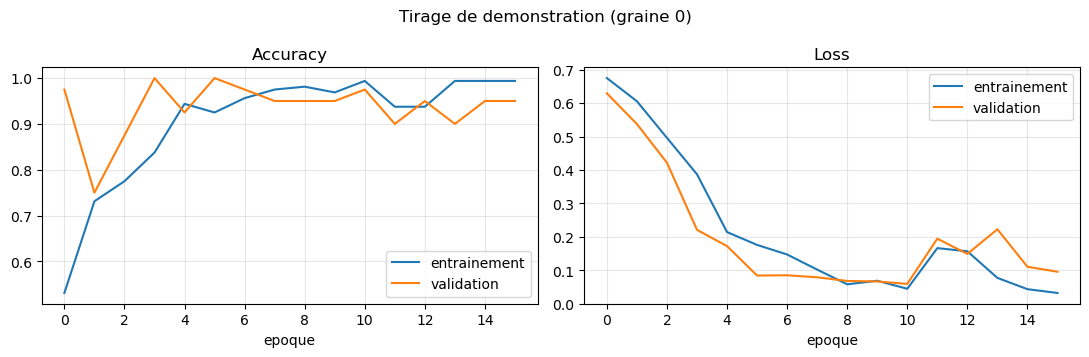

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(historique_demo["accuracy"], label="entrainement")
ax[0].plot(historique_demo["val_accuracy"], label="validation")
ax[0].set_title("Accuracy"); ax[0].set_xlabel("epoque"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(historique_demo["loss"], label="entrainement")
ax[1].plot(historique_demo["val_loss"], label="validation")
ax[1].set_title("Loss"); ax[1].set_xlabel("epoque"); ax[1].legend(); ax[1].grid(alpha=.3)
fig.suptitle("Tirage de demonstration (graine 0)")
plt.tight_layout()
plt.savefig("resultats/courbes-demo.png", dpi=130)
plt.show()

In [7]:
from figstyle import SEQUENTIAL
from cnn import load_images

x_test, y_test = load_images(test, IMG)
proba_test = modele_demo.predict(x_test, batch_size=64, verbose=0).ravel()
pred_test = (proba_test >= 0.5).astype(int)

# Meme presentation que 01-parking-lbp/figures.py::figure_matrice_confusion
matrice = np.array([[int(((y_test == v) & (pred_test == p)).sum())
                     for p in (0, 1)] for v in (0, 1)])

fig, ax = plt.subplots(figsize=(4.2, 4.0))
rampe = plt.matplotlib.colors.LinearSegmentedColormap.from_list("bleu", SEQUENTIAL)
ax.imshow(matrice, cmap=rampe, vmin=0, vmax=matrice.max())
for i in range(2):
    for j in range(2):
        fonce = matrice[i, j] > 0.55 * matrice.max()
        ax.text(j, i, matrice[i, j], ha="center", va="center", fontsize=15,
               fontweight="bold", color="#ffffff" if fonce else "#0b0b0b")
ax.set_xticks((0, 1), ("libre", "occupe"))
ax.set_yticks((0, 1), ("libre", "occupe"))
ax.set_xlabel("classe predite par le modele")
ax.set_ylabel("classe reelle de l'image")
ax.set_title("Matrice de confusion - tirage de demonstration (graine 0)\n%.2f %% d'images test bien reconnues" % taux_demo)
ax.grid(False)
ax.tick_params(length=0)
for cote in ax.spines.values():
    cote.set_visible(False)
plt.tight_layout()
plt.savefig("resultats/matrice-confusion-demo.png", dpi=130)
plt.show()

C:\Users\e2500138\AppData\Local\Temp\ipykernel_11860\1840199192.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 4. Repetition sur 10 tirages independants

Meme boucle que `04-parking-lbp-multiechelle/benchmark.py`, avec le meme
schema de graine (`tirage * 2`) : chaque tirage entraine un CNN neuf (poids
reinitialises) sur ses 200 imagettes training, et l'evalue sur ses 200
imagettes test. Comptez plusieurs minutes sur CPU (30 epoques au plus,
arret anticipe generalement bien avant, par tirage).

In [8]:
N_RUNS = 10
taux_cnn = []

for tirage in range(N_RUNS):
    tr, te = tirages(TRAIN_ROOT, TRAIN_ROOT, 100, 100, seed=tirage * 2)
    t0 = time.time()
    valeur, _, _ = train_and_evaluate(tr, te, seed=tirage, epochs=30, patience=5, verbose=0)
    taux_cnn.append(valeur)
    print("tirage %d/%d : %6.2f %%  (%.0f s)" % (tirage + 1, N_RUNS, valeur, time.time() - t0))

taux_cnn = np.array(taux_cnn)
print("\nMoyenne %.2f %% | Ecart-type %.2f | Min %.2f %% | Max %.2f %%"
      % (taux_cnn.mean(), taux_cnn.std(), taux_cnn.min(), taux_cnn.max()))

tirage 1/10 :  99.00 %  (3 s)


tirage 2/10 :  97.50 %  (4 s)


tirage 3/10 :  95.50 %  (2 s)


tirage 4/10 :  97.50 %  (3 s)


tirage 5/10 :  99.00 %  (4 s)


tirage 6/10 :  97.50 %  (2 s)


tirage 7/10 :  97.50 %  (4 s)


tirage 8/10 :  97.00 %  (3 s)


tirage 9/10 :  99.50 %  (4 s)


tirage 10/10 :  96.50 %  (3 s)

Moyenne 97.65 % | Ecart-type 1.16 | Min 95.50 % | Max 99.50 %


In [9]:
import csv
from pathlib import Path

Path("resultats").mkdir(exist_ok=True)
with open("resultats/benchmark.csv", "w", newline="", encoding="ascii") as f:
    writer = csv.writer(f)
    writer.writerow(("mode", "tirage", "taux"))
    for tirage, valeur in enumerate(taux_cnn):
        writer.writerow(("cnn", tirage, "%.2f" % valeur))
print("ecrit : resultats/benchmark.csv")

ecrit : resultats/benchmark.csv


## 5. Graphe de synthese : la moyenne sur les 10 tirages

Meme lecture que la figure de synthese du TP 4 (`comparaison-modes.png`) :
un point par tirage, le point plein est la moyenne, le trait relie le min et
le max.

In [10]:
from figures import figure_benchmark
from figstyle import SERIES

figure_benchmark(
    {"cnn": list(taux_cnn)}, "resultats/benchmark-cnn.png",
    "Taux de reconnaissance du CNN sur %d tirages independants" % N_RUNS,
    couleurs={"cnn": SERIES[0]})

figure : resultats/benchmark-cnn.png


## 6. Comparaison au descripteur LBP (TP 01-04)

Les graines etant identiques, `04-parking-lbp-multiechelle/resultats/benchmark.csv`
contient le taux du descripteur LBP **sur ces memes tirages**, donc sur les
memes imagettes. La comparaison ci-dessous n'oppose donc pas deux moyennes
issues de tirages differents, mais la meme experience, methode par methode.

In [11]:
from figures import figure_ecarts_cnn, lire_benchmark

taux_lbp = lire_benchmark("../04-parking-lbp-multiechelle/resultats/benchmark.csv")

combine = {
    "cnn": list(taux_cnn),
    "lbp global": taux_lbp["global"],
    "lbp pyramide": taux_lbp["pyramide"],
}
couleurs = {"cnn": SERIES[0], "lbp global": SERIES[1], "lbp pyramide": SERIES[2]}
figure_benchmark(combine, "resultats/comparaison-cnn-lbp.png",
                 "CNN face au descripteur LBP (TP 01-04), memes tirages",
                 couleurs=couleurs)

figure : resultats/comparaison-cnn-lbp.png


In [12]:
figure_ecarts_cnn(list(taux_cnn), taux_lbp["global"], "LBP global",
                  "resultats/ecarts-cnn-vs-lbp.png")

figure : resultats/ecarts-cnn-vs-lbp.png


## 7. Conclusion (generee a partir des resultats)

In [13]:
moyenne_cnn = taux_cnn.mean()
moyenne_lbp_global = np.mean(taux_lbp["global"])
moyenne_lbp_pyramide = np.mean(taux_lbp["pyramide"])
ecarts = taux_cnn - np.array(taux_lbp["global"])

lignes = []
lignes.append("CNN            : %.2f %% de moyenne sur %d tirages (ecart-type %.2f)"
              % (moyenne_cnn, N_RUNS, taux_cnn.std()))
lignes.append("LBP global     : %.2f %% (reference, TP 01/04)" % moyenne_lbp_global)
lignes.append("LBP pyramide   : %.2f %% (meilleur mode du TP 4)" % moyenne_lbp_pyramide)
lignes.append("")

if moyenne_cnn > moyenne_lbp_pyramide:
    lignes.append("Sur ce jeu, le CNN depasse le meilleur descripteur LBP de %.2f point en moyenne."
                  % (moyenne_cnn - moyenne_lbp_pyramide))
elif moyenne_cnn > moyenne_lbp_global:
    lignes.append("Le CNN depasse le descripteur LBP global (%.2f point) sans egaler le meilleur "
                  "mode multi-echelle (%.2f point d'ecart)."
                  % (moyenne_cnn - moyenne_lbp_global, moyenne_lbp_pyramide - moyenne_cnn))
else:
    lignes.append("Sur ce jeu et avec ce protocole (200 imagettes training, CNN entraine de zero), "
                  "le CNN n'egale pas le descripteur LBP (%.2f point d'ecart avec la reference globale). "
                  "Le LBP, invariant aux changements monotones d'intensite et sans risque de "
                  "sur-apprentissage sur un aussi petit jeu, reste avantage sur ce protocole precis."
                  % (moyenne_lbp_global - moyenne_cnn))

lignes.append("Comparaison appariee (memes imagettes, tirage par tirage) : ecart moyen %+.2f point, "
              "de %+.2f a %+.2f selon le tirage." % (ecarts.mean(), ecarts.min(), ecarts.max()))
lignes.append("")
lignes.append("Portee du resultat : le CNN est entraine de zero sur seulement 200 imagettes, sans "
              "pre-entrainement (pas de transfert depuis ImageNet, contrairement a MobileNetV2 dans "
              "le TP malware). Avec davantage de donnees d'entrainement, l'ecart attendu se creuserait "
              "en faveur du CNN ; a 200 imagettes, un descripteur fait main bien choisi reste competitif.")

CONCLUSION = "\n".join(lignes)
print(CONCLUSION)

with open("resultats/conclusion.txt", "w", encoding="utf-8") as f:
    f.write(CONCLUSION + "\n")

CNN            : 97.65 % de moyenne sur 10 tirages (ecart-type 1.16)
LBP global     : 97.20 % (reference, TP 01/04)
LBP pyramide   : 98.05 % (meilleur mode du TP 4)

Le CNN depasse le descripteur LBP global (0.45 point) sans egaler le meilleur mode multi-echelle (0.40 point d'ecart).
Comparaison appariee (memes imagettes, tirage par tirage) : ecart moyen +0.45 point, de -2.00 a +4.00 selon le tirage.

Portee du resultat : le CNN est entraine de zero sur seulement 200 imagettes, sans pre-entrainement (pas de transfert depuis ImageNet, contrairement a MobileNetV2 dans le TP malware). Avec davantage de donnees d'entrainement, l'ecart attendu se creuserait en faveur du CNN ; a 200 imagettes, un descripteur fait main bien choisi reste competitif.
